# **Customer Lifetime Value (CLV) Analysis EDA.**

## **Load Data.**

In [1]:
import os
import pandas as pd

DATASETS_PATH = os.getenv("DATASETS_PATH")
DATASETS_PATH = DATASETS_PATH + "/CustomerLifeValue/EcommerceOlist/"

customers_df = pd.read_csv(DATASETS_PATH + "olist_customers_dataset.csv")

order_items_df = pd.read_csv(DATASETS_PATH + "olist_order_items_dataset.csv")

payments_df = pd.read_csv(DATASETS_PATH + "olist_order_payments_dataset.csv")

payments_df = pd.read_csv(DATASETS_PATH + "olist_order_payments_dataset.csv")

orders_df = pd.read_csv(DATASETS_PATH + "olist_orders_dataset.csv")


## **Merge tables relevant to CLV.**

For CLV we need a table of transactions, so that we can model future customer revenue values.

In [2]:
payments_agg = (
    payments_df
    .groupby("order_id")
    .agg({
        "payment_value": "sum",
        "payment_installments": "max" # Describes in how many parts the resulting sum is payed (payment behaviour feature)
    })
    .reset_index()
)

clv_df = (
    orders_df
    .merge(customers_df, on="customer_id")
    .merge(payments_agg, on="order_id")
)

print(clv_df)

                               order_id                       customer_id  \
0      e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1      53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2      47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3      949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4      ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
...                                 ...                               ...   
99435  9c5dedf39a927c1b2549525ed64a053c  39bd1228ee8140590ac3aca26f2dfe00   
99436  63943bddc261676b46f01ca7ac2f7bd8  1fca14ff2861355f6e5f14306ff977a7   
99437  83c1379a015df1e13d02aae0204711ab  1aa71eb042121263aafbe80c1b562c9c   
99438  11c177c8e97725db2631073c19f07b62  b331b74b18dc79bcdf6532d51e1637c1   
99439  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

      order_status order_purchase_timestamp    order_approved_at  \
0      

## **Drop unnecessary columns.**

In [3]:

drop_cols = [
    "customer_id",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_estimated_delivery_date"
]

clv_df = clv_df.drop(columns = drop_cols)

print(clv_df)

                               order_id order_status order_purchase_timestamp  \
0      e481f51cbdc54678b7cc49136f2d6af7    delivered      2017-10-02 10:56:33   
1      53cdb2fc8bc7dce0b6741e2150273451    delivered      2018-07-24 20:41:37   
2      47770eb9100c2d0c44946d9cf07ec65d    delivered      2018-08-08 08:38:49   
3      949d5b44dbf5de918fe9c16f97b45f8a    delivered      2017-11-18 19:28:06   
4      ad21c59c0840e6cb83a9ceb5573f8159    delivered      2018-02-13 21:18:39   
...                                 ...          ...                      ...   
99435  9c5dedf39a927c1b2549525ed64a053c    delivered      2017-03-09 09:54:05   
99436  63943bddc261676b46f01ca7ac2f7bd8    delivered      2018-02-06 12:58:58   
99437  83c1379a015df1e13d02aae0204711ab    delivered      2017-08-27 14:46:43   
99438  11c177c8e97725db2631073c19f07b62    delivered      2018-01-08 21:28:27   
99439  66dea50a8b16d9b4dee7af250b4be1a5    delivered      2018-03-08 20:57:30   

      order_delivered_custo

## **Check the data quality and distributions.** 

Check **order status** distribution in the table.

In [4]:
print(clv_df["order_status"].value_counts())

order_status
delivered      96477
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


For CLV we are interested only in transactions, that have status **'delievered'**.

In [5]:
clv_df = clv_df[
    clv_df["order_status"] == "delivered"
]

Let's check now how **payments values** are distributed.

In [6]:
print(clv_df["payment_value"].describe())

count    96477.000000
mean       159.856357
std        218.813144
min          9.590000
25%         61.880000
50%        105.280000
75%        176.330000
max      13664.080000
Name: payment_value, dtype: float64


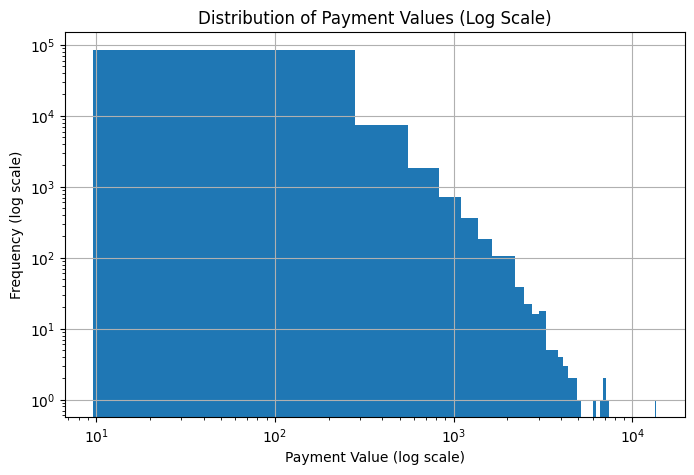

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(clv_df["payment_value"], bins=50)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Payment Value (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Distribution of Payment Values (Log Scale)")

plt.grid(True)

plt.show()

Now, we are going to generate **cumulative revenue curves**.

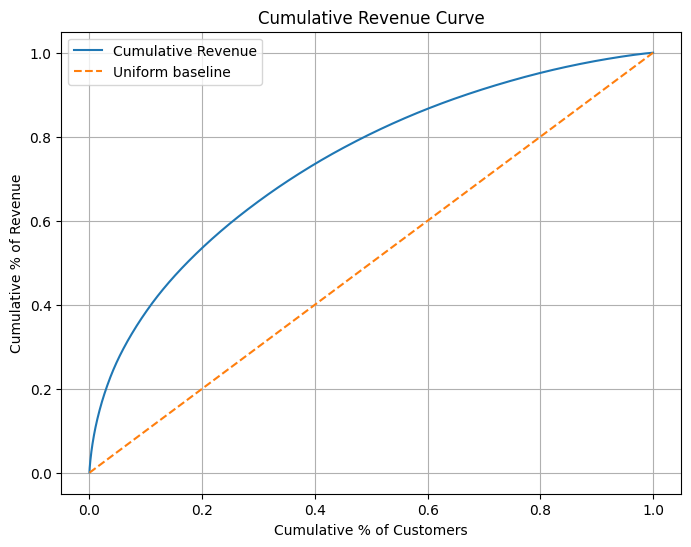

In [10]:
import numpy as np

customer_rev = (
    clv_df.groupby("customer_unique_id")["payment_value"]
    .sum()
    .sort_values(ascending=False)
)

cum_rev = customer_rev.cumsum()

cum_rev_pct = cum_rev / cum_rev.iloc[-1]

customer_pct = np.arange(1, len(cum_rev_pct) + 1) / len(cum_rev_pct)

plt.figure(figsize=(8,6))

plt.plot(customer_pct, cum_rev_pct, label="Cumulative Revenue")

# Optional equality line
plt.plot([0,1], [0,1], linestyle="--", label="Uniform baseline")

plt.xlabel("Cumulative % of Customers")
plt.ylabel("Cumulative % of Revenue")

plt.title("Cumulative Revenue Curve")
plt.legend()
plt.grid(True)

plt.show()

The cumulative revenue curve indicates that approximately 50% of customers contribute to 80% of total revenue, suggesting a moderately concentrated revenue distribution. Unlike extreme Pareto systems where a small fraction of customers dominates revenue, this dataset shows a broader contribution base, implying that mid-value customers are critical drivers of overall business performance.